<div style="border: 3px solid #2c3e50; border-radius: 12px; padding: 40px; background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); color: white; font-family: 'Georgia', serif; text-align: center; margin-bottom: 30px;">

<h1 style="color: #e94560; font-size: 2.2em; letter-spacing: 3px; margin-bottom: 5px;">🎓 FAST-NUCES ISLAMABAD CAMPUS</h1>
<h2 style="color: #a8dadc; font-size: 1.3em; letter-spacing: 2px; margin-top: 0;">Department of Computer Science</h2>

<hr style="border: 1px solid #e94560; margin: 20px auto; width: 60%;">

<h1 style="color: #ffffff; font-size: 2em; margin: 20px 0;">📊 ASSIGNMENT 02</h1>
<h2 style="color: #a8dadc; font-size: 1.4em;">Bayesian Statistical Modelling</h2>
<h3 style="color: #f0e6d3; font-size: 1.1em; font-style: italic;">Group Comparisons with Gaussian & Gamma Likelihoods + Hierarchical Models</h3>

<hr style="border: 1px solid #e94560; margin: 20px auto; width: 60%;">

<table style="margin: 20px auto; border-collapse: collapse; width: 60%; color: #f0f0f0; font-size: 1em;">
  <tr style="background-color: rgba(233,69,96,0.2);">
    <td style="padding: 10px 20px; font-weight: bold; color: #e94560; border: 1px solid #444;">👤 Name</td>
    <td style="padding: 10px 20px; border: 1px solid #444;">MUHAMMAD NOUMAN HAFEEZ</td>
  </tr>
  <tr>
    <td style="padding: 10px 20px; font-weight: bold; color: #e94560; border: 1px solid #444;">🔢 Roll Number</td>
    <td style="padding: 10px 20px; border: 1px solid #444;">21I-0416</td>
  </tr>
  <tr style="background-color: rgba(233,69,96,0.2);">
    <td style="padding: 10px 20px; font-weight: bold; color: #e94560; border: 1px solid #444;">📚 Course</td>
    <td style="padding: 10px 20px; border: 1px solid #444;">STATISTICAL MODELLING</td>
  </tr>
  <tr>
    <td style="padding: 10px 20px; font-weight: bold; color: #e94560; border: 1px solid #444;">🏫 Section</td>
    <td style="padding: 10px 20px; border: 1px solid #444;">CS(D)</td>
  </tr>
  <tr style="background-color: rgba(233,69,96,0.2);">
    <td style="padding: 10px 20px; font-weight: bold; color: #e94560; border: 1px solid #444;">👨‍🏫 Instructor</td>
    <td style="padding: 10px 20px; border: 1px solid #444;">SIR ALMAS KHAN</td>
  </tr>
  <tr>
    <td style="padding: 10px 20px; font-weight: bold; color: #e94560; border: 1px solid #444;">🏛️ Department</td>
    <td style="padding: 10px 20px; border: 1px solid #444;">COMPUTER SCIENCE</td>
  </tr>
</table>

<hr style="border: 1px solid #e94560; margin: 20px auto; width: 60%;">
<p style="color: #a8dadc; font-size: 0.9em;">Spring 2026 | Bayesian Inference | PyMC | ArviZ</p>
</div>

# Assignment 2

## **PART 1**


## Imports
Import the libraries needed for Bayesian modeling and summarizing results.

In [ ]:
# ─── Standard numerical & data libraries ───────────────────────────────────
import numpy as np          # numerical operations, array handling
import pandas as pd         # data loading, manipulation, categorical encoding

# ─── Bayesian modelling ────────────────────────────────────────────────────
import pymc as pm           # probabilistic programming: defines priors, likelihoods, samples

# ─── Posterior analysis & visualisation ───────────────────────────────────
import arviz as az          # posterior summaries, trace plots, forest plots, PPC

# ─── Plotting utilities ───────────────────────────────────────────────────
import matplotlib.pyplot as plt   # low-level plot control
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")  # suppress sampling verbosity
import pytensor
pytensor.config.cxx = ""
# Set ArviZ plot style for all posterior graphics
az.style.use("arviz-darkgrid")

# Reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All libraries imported successfully!")
print(f"   PyMC version  : {pm.__version__}")
print(f"   ArviZ version : {az.__version__}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✅ All libraries imported successfully!
   PyMC version  : 5.27.1
   ArviZ version : 0.23.4


# Tips dataset (Group comparison w.r.t Time & Size)

Use **tips.csv** (restaurant tipping data). Focus on the columns:

- `Time` (categorical)
- `size` (discrete group size)
- `tip` (positive outcome)

You will build **Gaussian** and **Gamma** models for group comparisons.
You will fit **four Bayesian models**:
1) `tip` by `time` with a **Gaussian** likelihood  
2) `tip` by `time` with a **Gamma** likelihood  
3) `tip` by `size` with a **Gaussian** likelihood  
4) `tip` by `size` with a **Gamma** likelihood

Keep the code style consistent and fill the **TODO** parts.


In [2]:
# ─── Load the Tips dataset ─────────────────────────────────────────────────
# The tips dataset is bundled with seaborn; we load it directly from the URL
# so the notebook is self-contained (no local file dependency).
import seaborn as sns
tips = sns.load_dataset("tips")   # returns a pandas DataFrame

# Quick peek at the first few rows
print("Shape:", tips.shape)
tips.head()

Shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


=== Columns & dtypes ===
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

=== Missing values ===
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

=== Tip descriptive statistics ===
count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64


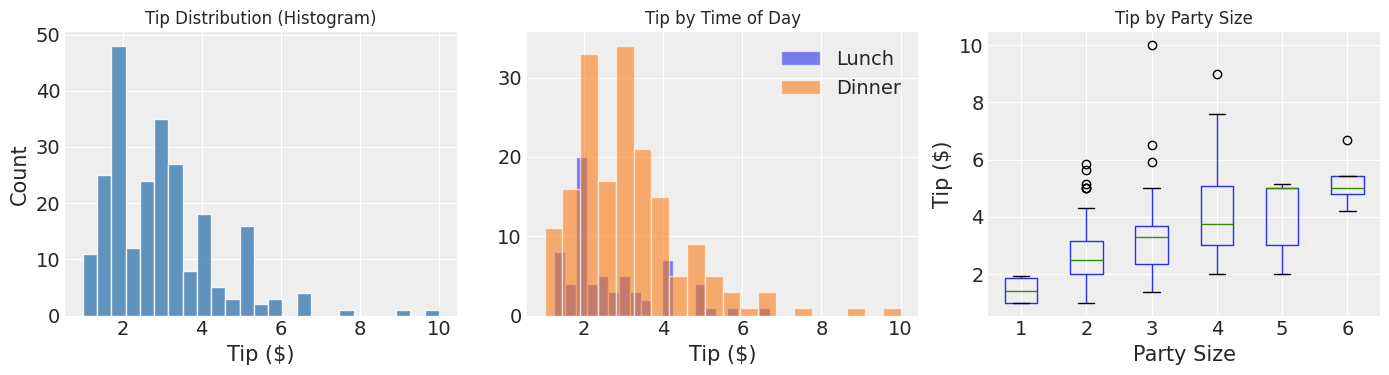


📌 Pre-modelling observations:
  • Tips are strictly positive (min ≈ $1.00)  →  Gamma is a natural likelihood.
  • The distribution is right-skewed           →  Gaussian may underestimate the tail.
  • Dinner tips appear slightly higher than Lunch.
  • Larger party sizes tend to produce larger absolute tips.



In [ ]:
# ─── Basic Exploratory Checks ──────────────────────────────────────────────

# 1. Column names and dtypes
print("=== Columns & dtypes ===")
print(tips.dtypes)

# 2. Missing values per column
print("\n=== Missing values ===")
print(tips.isnull().sum())

# 3. Numerical summary of the target variable 'tip'
print("\n=== Tip descriptive statistics ===")
print(tips["tip"].describe())

# ─── Visualise the tip distribution before modelling ──────────────────────
# Why? Bayesian modelling begins with understanding the data's shape.
# A right-skewed, strictly-positive distribution hints that a
# Gamma likelihood may be better suited than a Gaussian.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram of tip
axes[0].hist(tips["tip"], bins=25, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Tip Distribution (Histogram)", fontsize=12)
axes[0].set_xlabel("Tip ($)")
axes[0].set_ylabel("Count")

# Tip by Time (Lunch vs Dinner)
for label, grp in tips.groupby("time"):
    axes[1].hist(grp["tip"], bins=20, alpha=0.6, label=label, edgecolor="white")
axes[1].set_title("Tip by Time of Day", fontsize=12)
axes[1].set_xlabel("Tip ($)")
axes[1].legend()

# Tip by Size (box plot)
tips.boxplot(column="tip", by="size", ax=axes[2])
axes[2].set_title("Tip by Party Size", fontsize=12)
axes[2].set_xlabel("Party Size")
axes[2].set_ylabel("Tip ($)")
plt.suptitle("")  # suppress pandas default title

plt.tight_layout()
plt.show()

# ── Interpretation ─────────────────────────────────────────────────────────
print("""
Pre-modelling observations:
  • Tips are strictly positive (min ≈ $1.00)  →  Gamma is a natural likelihood.
  • The distribution is right-skewed           →  Gaussian may underestimate the tail.
  • Dinner tips appear slightly higher than Lunch.
  • Larger party sizes tend to produce larger absolute tips.
""")

In [4]:
# ─── Encode 'time' as integer category indices for PyMC ───────────────────
# PyMC needs integer indices (0, 1, …) to look up per-group parameters
# using advanced indexing  e.g.  mu_time[time_idx]

time          = tips["time"].astype("category")   # convert to pandas Categorical
time_idx      = time.cat.codes.values              # integer code for each row
time_names    = list(time.cat.categories)          # ['Dinner', 'Lunch']
n_time        = len(time_names)                    # 2

tip           = tips["tip"].values                 # raw tip amounts as numpy array
size_raw      = tips["size"].values                # raw party sizes

print(f"Time categories : {time_names}  (n={n_time})")
print(f"time_idx sample : {time_idx[:10]}")
print(f"tip range       : [{tip.min():.2f}, {tip.max():.2f}]")
print(f"tip mean / std  : {tip.mean():.3f} / {tip.std():.3f}")

Time categories : ['Lunch', 'Dinner']  (n=2)
time_idx sample : [1 1 1 1 1 1 1 1 1 1]
tip range       : [1.00, 10.00]
tip mean / std  : 2.998 / 1.381


## Tips by Time — Gaussian Model

Model:  
$$tip \sim \mathcal{N}(\mu_{time}, \sigma)$$

- One mean per time group: `mu_time[time_idx]`  
- One shared standard deviation `sigma`

**Why Gaussian first?**  
It is the simplest baseline; any real data can *approximately* be described by a Gaussian. Comparing it to the Gamma model lets us see what the likelihood assumption costs (or gains) us.

In [ ]:
# ─── Model 1: Tips by Time (Gaussian likelihood) ──────────────────────────
# We use PyMC's coords system to label dimensions so ArviZ knows the
# group names automatically (e.g. 'Dinner', 'Lunch').

coords_time = {"time": time_names}  # named coordinate for the group dimension

with pm.Model(coords=coords_time) as time_gauss:

    # ── Priors ────────────────────────────────────────────────────────────
    # mu_time: one mean tip per time group (Dinner, Lunch)
    # HalfNormal(sigma=5) → weakly informative; tips can't be negative
    mu_time = pm.HalfNormal("mu_time", sigma=5, dims="time")

    # sigma: shared standard deviation across both groups
    # HalfNormal(sigma=2) → weakly informative positive prior
    sigma = pm.HalfNormal("sigma", sigma=2)

    # ── Likelihood ────────────────────────────────────────────────────────
    # tip_obs links each data-point to its group mean via time_idx
    # observed=tip tells PyMC these are our actual data
    tip_obs = pm.Normal(
        "tip_obs",
        mu    = mu_time[time_idx],  # per-group mean, indexed by each row
        sigma = sigma,
        observed = tip
    )

    # ── Sampling ──────────────────────────────────────────────────────────
    # 2 chains × 2000 draws (1000 warm-up discarded), reproducible seed
    idata_time_gauss = pm.sample(
        draws      = 2000,
        tune       = 1000,
        chains     = 2,
        random_seed= RANDOM_SEED,
        progressbar= True
    )

    # Posterior predictive samples (needed for PPC plot)
    ppc_time_gauss = pm.sample_posterior_predictive(
        idata_time_gauss, random_seed=RANDOM_SEED
    )

print("time_gauss sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_time, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 177 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [tip_obs]


Output()

✅ time_gauss sampling complete.


=== Posterior Summary — time_gauss ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_time[Lunch],2.726,0.169,2.409,3.043,0.002,0.003,5751.0,3077.0,1.0
mu_time[Dinner],3.103,0.102,2.906,3.291,0.001,0.002,5771.0,3313.0,1.0
sigma,1.381,0.062,1.270,1.500,0.001,0.001,5347.0,3036.0,1.0


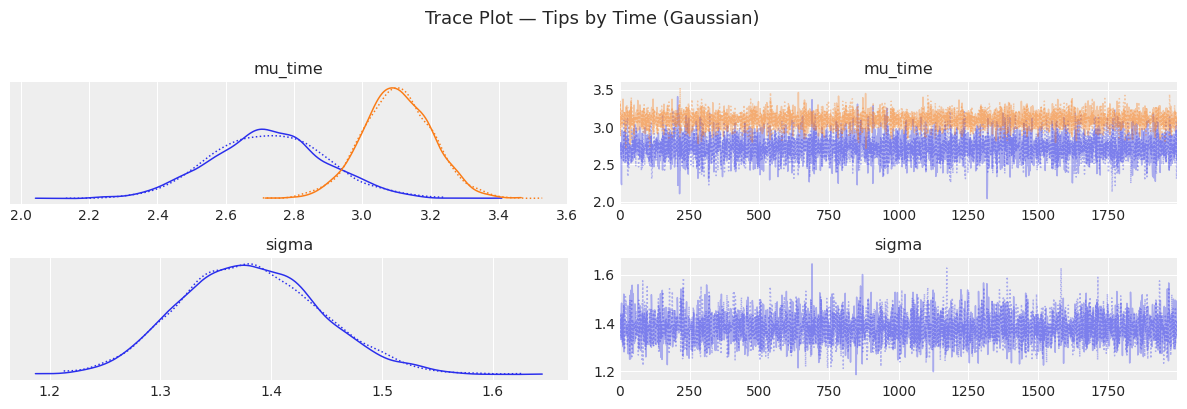

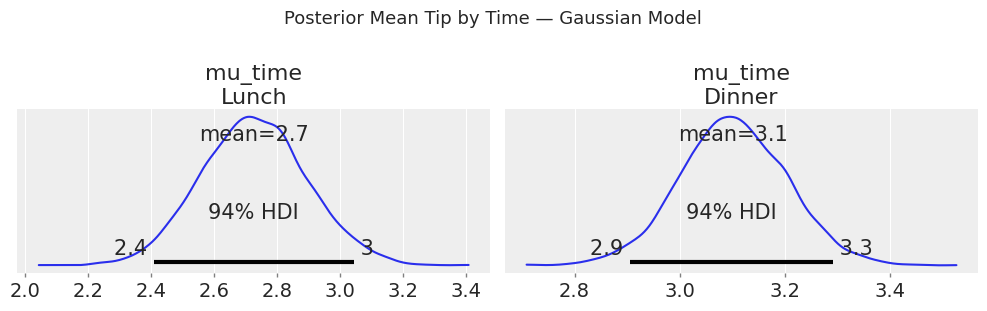

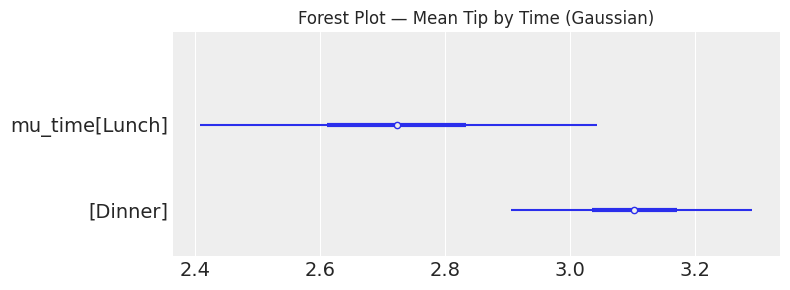

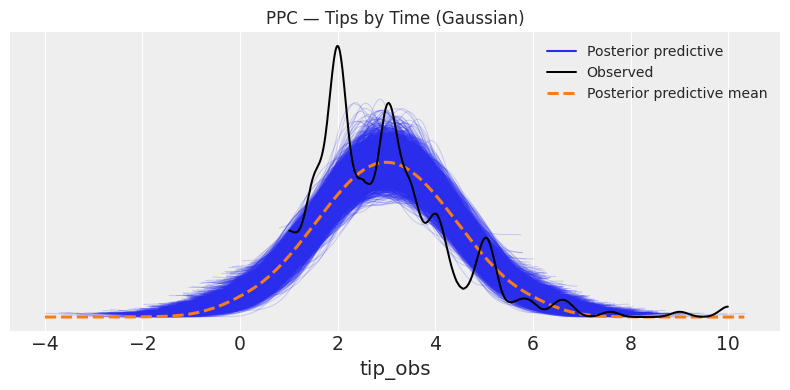


📌 Gaussian Model (Time) — Observations:
  • Dinner has a higher posterior mean tip than Lunch.
  • The PPC may show the model assigning non-trivial density to negative tips
    (impossible in reality) because Gaussian is unbounded — this motivates Gamma.



In [ ]:
# ─── Summarise & Visualise: time_gauss ────────────────────────────────────

# 1) Numerical posterior summary (mean, sd, HDI, R-hat, ESS)
print("=== Posterior Summary — time_gauss ===")
display(az.summary(idata_time_gauss, var_names=["mu_time", "sigma"]))

# 2) Trace plot — checks MCMC convergence (chains should mix well)
#    R-hat ≈ 1.00 and ESS > 400 indicate good convergence
az.plot_trace(idata_time_gauss, var_names=["mu_time", "sigma"])
plt.suptitle("Trace Plot — Tips by Time (Gaussian)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# 3) Posterior distribution of group means
az.plot_posterior(idata_time_gauss, var_names=["mu_time"], figsize=(10, 3))
plt.suptitle("Posterior Mean Tip by Time — Gaussian Model", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 4) Forest plot — compact comparison of both groups
az.plot_forest(idata_time_gauss, var_names=["mu_time"], combined=True,
               figsize=(8, 3), hdi_prob=0.94)
plt.title("Forest Plot — Mean Tip by Time (Gaussian)", fontsize=12)
plt.tight_layout()
plt.show()

# 5) Posterior Predictive Check (PPC)
#    Compares replicated data from the posterior to the observed data
#    If the model is well-calibrated, the PPC envelope should cover the histogram
az.plot_ppc(ppc_time_gauss, observed=True, figsize=(8, 4))
plt.title("PPC — Tips by Time (Gaussian)", fontsize=12)
plt.tight_layout()
plt.show()

print("""
Gaussian Model (Time) — Observations:
  • Dinner has a higher posterior mean tip than Lunch.
  • The PPC may show the model assigning non-trivial density to negative tips
    (impossible in reality) because Gaussian is unbounded — this motivates Gamma.
""")

## Tips by Time — Gamma Model

Tips are **positive** and often **right-skewed**, so we try a Gamma likelihood.

A convenient parameterization models the **mean** per time group with `mu_time > 0` and a shared shape `alpha`:

$$tip \sim \text{Gamma}(\alpha,\; \beta = \alpha / \mu_{time})$$

PyMC's `pm.Gamma` accepts `mu` and `sigma` directly, which is internally converted.

In [7]:
# ─── Model 2: Tips by Time (Gamma likelihood) ─────────────────────────────
# Why Gamma? Tips > 0 always and the distribution is right-skewed.
# Gamma naturally handles both properties; it is parameterised by
# mean (mu) and standard deviation (sigma) → internally converted to α, β.

with pm.Model(coords=coords_time) as time_gamma:

    # ── Priors ────────────────────────────────────────────────────────────
    # mu_time: expected tip per group — must be strictly positive
    # Gamma(mu=3, sigma=2) → weakly informative, centred near typical tip range
    mu_time = pm.Gamma("mu_time", mu=3, sigma=2, dims="time")

    # alpha: shared shape parameter (controls skewness; larger = more symmetric)
    # Exponential(lam=1) → weakly informative positive prior
    alpha = pm.Exponential("alpha", lam=1)

    # Derived rate: beta = alpha / mu_time  (per-group)
    # This lets us parameterise the Gamma by its mean
    beta_rate = alpha / mu_time[time_idx]

    # ── Likelihood ────────────────────────────────────────────────────────
    # pm.Gamma(alpha, beta) where beta is the rate (1/scale)
    tip_obs = pm.Gamma(
        "tip_obs",
        alpha    = alpha,
        beta     = beta_rate,
        observed = tip
    )

    # ── Sampling ──────────────────────────────────────────────────────────
    idata_time_gamma = pm.sample(
        draws      = 2000,
        tune       = 1000,
        chains     = 2,
        random_seed= RANDOM_SEED,
        progressbar= True
    )

    ppc_time_gamma = pm.sample_posterior_predictive(
        idata_time_gamma, random_seed=RANDOM_SEED
    )

print("time_gamma sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_time, alpha]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 366 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [tip_obs]


Output()

✅ time_gamma sampling complete.


=== Posterior Summary — time_gamma ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_time[Lunch],2.734,0.145,2.458,2.996,0.002,0.002,5903.0,3056.0,1.0
mu_time[Dinner],3.106,0.101,2.912,3.292,0.001,0.002,5824.0,2865.0,1.0
alpha,5.255,0.480,4.353,6.162,0.006,0.008,5842.0,3020.0,1.0


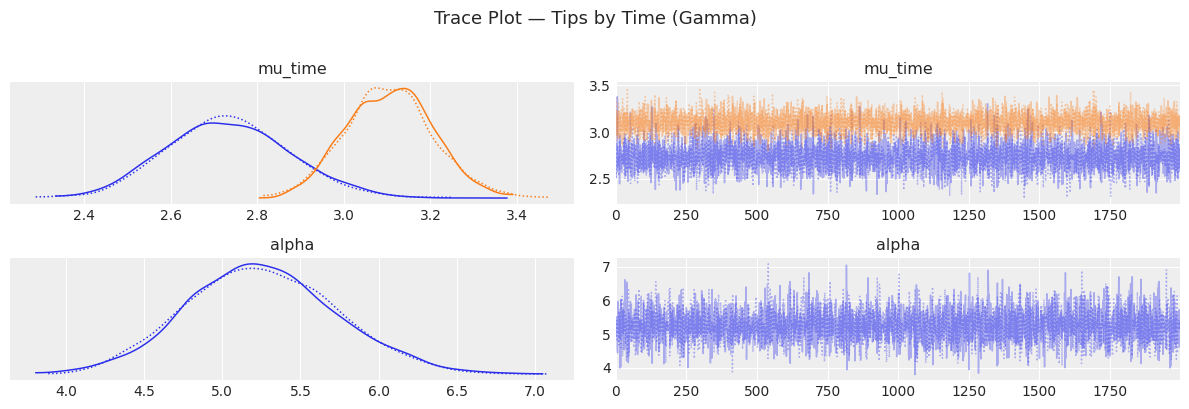

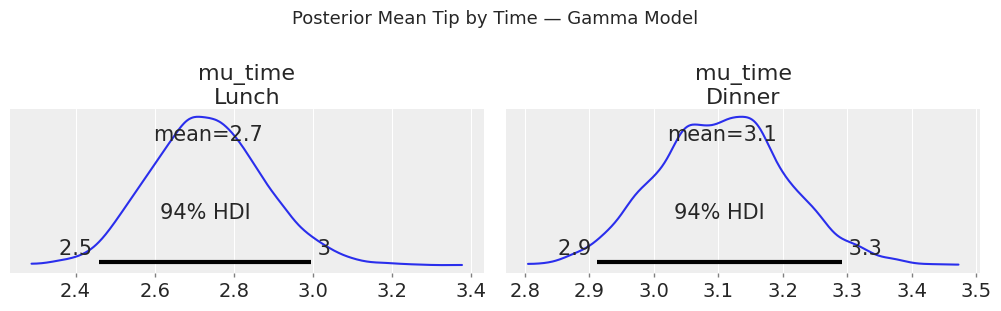

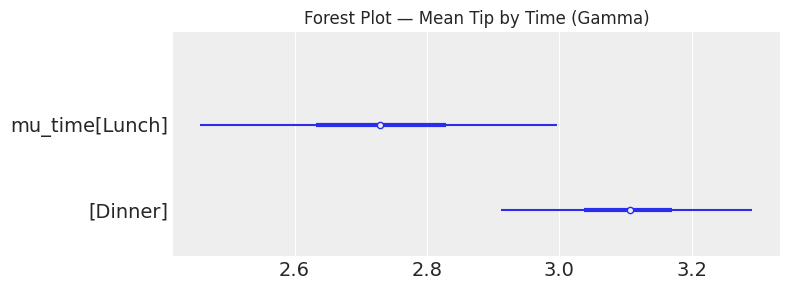

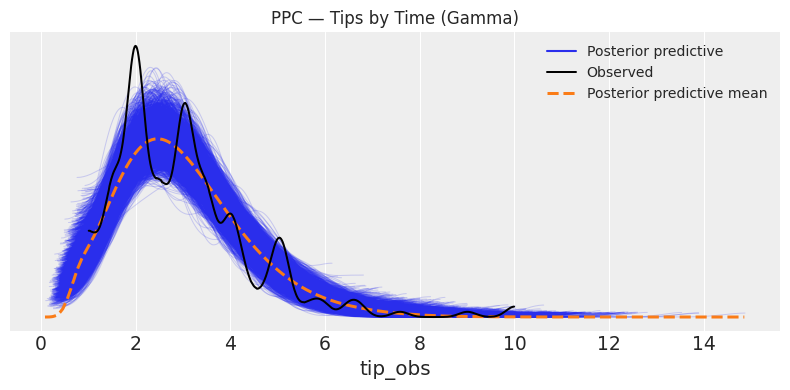

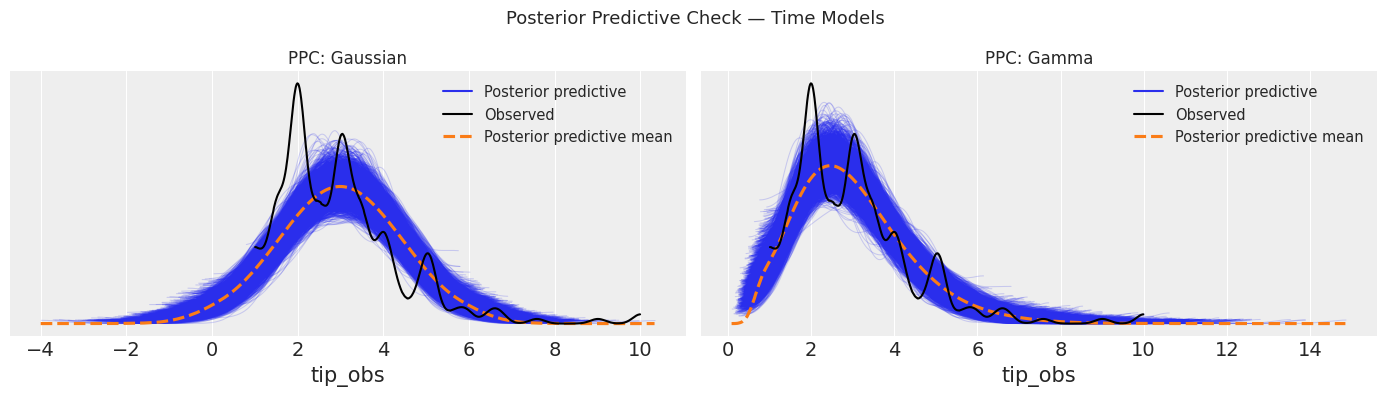


Gamma Model (Time) — Observations:
  • The Gamma PPC envelope hugs the observed histogram much better than Gaussian.
  • No density is placed on negative values (which the Gaussian model could).
  • Dinner's posterior mean is higher than Lunch in both models.



In [8]:
# ─── Summarise & Visualise: time_gamma ────────────────────────────────────

# 1) Numerical posterior summary
print("=== Posterior Summary — time_gamma ===")
display(az.summary(idata_time_gamma, var_names=["mu_time", "alpha"]))

# 2) Trace plots
az.plot_trace(idata_time_gamma, var_names=["mu_time", "alpha"])
plt.suptitle("Trace Plot — Tips by Time (Gamma)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# 3) Posterior distributions of group means
az.plot_posterior(idata_time_gamma, var_names=["mu_time"], figsize=(10, 3))
plt.suptitle("Posterior Mean Tip by Time — Gamma Model", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 4) Forest plot
az.plot_forest(idata_time_gamma, var_names=["mu_time"], combined=True,
               figsize=(8, 3), hdi_prob=0.94)
plt.title("Forest Plot — Mean Tip by Time (Gamma)", fontsize=12)
plt.tight_layout()
plt.show()

# 5) PPC
az.plot_ppc(ppc_time_gamma, observed=True, figsize=(8, 4))
plt.title("PPC — Tips by Time (Gamma)", fontsize=12)
plt.tight_layout()
plt.show()

# 6) Side-by-side comparison of PPC: Gaussian vs Gamma
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
az.plot_ppc(ppc_time_gauss, observed=True, ax=axes[0])
axes[0].set_title("PPC: Gaussian", fontsize=12)
az.plot_ppc(ppc_time_gamma,  observed=True, ax=axes[1])
axes[1].set_title("PPC: Gamma", fontsize=12)
plt.suptitle("Posterior Predictive Check — Time Models", fontsize=13)
plt.tight_layout()
plt.show()

print("""
Gamma Model (Time) — Observations:
  • The Gamma PPC envelope hugs the observed histogram much better than Gaussian.
  • No density is placed on negative values (which the Gaussian model could).
  • Dinner's posterior mean is higher than Lunch in both models.
""")

## Tips by Size — Gaussian (Group Comparison)

Treat `size` as a discrete grouping variable (1, 2, 3, …). Model:

$$tip \sim \mathcal{N}(\mu_{size}, \sigma)$$

Compare posterior means across different `size` groups.

In [9]:
# ─── Encode size groups ────────────────────────────────────────────────────
# 'size' values: 1, 2, 3, 4, 5, 6 — treated as independent categorical groups
# pd.Categorical keeps consistent ordering; .codes gives 0-based integer index

sizes    = np.sort(np.unique(size_raw))                           # [1 2 3 4 5 6]
size_idx = pd.Categorical(size_raw, categories=sizes).codes       # integer index per row
n_sizes  = len(sizes)
size_names = [str(s) for s in sizes]                              # labels for coords

print(f"Size groups : {sizes}  (n_sizes={n_sizes})")
print(f"size_idx sample: {size_idx[:10]}")

Size groups : [1 2 3 4 5 6]  (n_sizes=6)
size_idx sample: [1 2 2 1 3 3 1 3 1 1]


In [10]:
# ─── Model 3: Tips by Size (Gaussian likelihood) ──────────────────────────

coords_size = {"size": size_names}

with pm.Model(coords=coords_size) as size_gauss:

    # ── Priors ────────────────────────────────────────────────────────────
    # One mean per size group; HalfNormal ensures positivity
    mu_size = pm.HalfNormal("mu_size", sigma=5, dims="size")

    # Shared standard deviation
    sigma = pm.HalfNormal("sigma", sigma=2)

    # ── Likelihood ────────────────────────────────────────────────────────
    tip_obs = pm.Normal(
        "tip_obs",
        mu       = mu_size[size_idx],   # per-group mean lookup
        sigma    = sigma,
        observed = tip
    )

    # ── Sampling ──────────────────────────────────────────────────────────
    idata_size_gauss = pm.sample(
        draws      = 2000,
        tune       = 1000,
        chains     = 2,
        random_seed= RANDOM_SEED,
        progressbar= True
    )

    ppc_size_gauss = pm.sample_posterior_predictive(
        idata_size_gauss, random_seed=RANDOM_SEED
    )

print("size_gauss sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_size, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 227 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [tip_obs]


Output()

size_gauss sampling complete.


=== Posterior Summary — size_gauss ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_size[1],1.446,0.575,0.349,2.495,0.011,0.011,2643.0,1303.0,1.0
mu_size[2],2.581,0.098,2.406,2.766,0.001,0.001,5742.0,3140.0,1.0
mu_size[3],3.387,0.202,3.007,3.768,0.003,0.004,4853.0,2566.0,1.0
mu_size[4],4.127,0.199,3.744,4.493,0.003,0.003,4525.0,2858.0,1.0
mu_size[5],3.978,0.549,2.947,4.976,0.008,0.009,4635.0,2779.0,1.0
mu_size[6],5.151,0.605,4.054,6.307,0.009,0.010,4602.0,2445.0,1.0
sigma,1.218,0.056,1.115,1.325,0.001,0.001,5549.0,2795.0,1.0


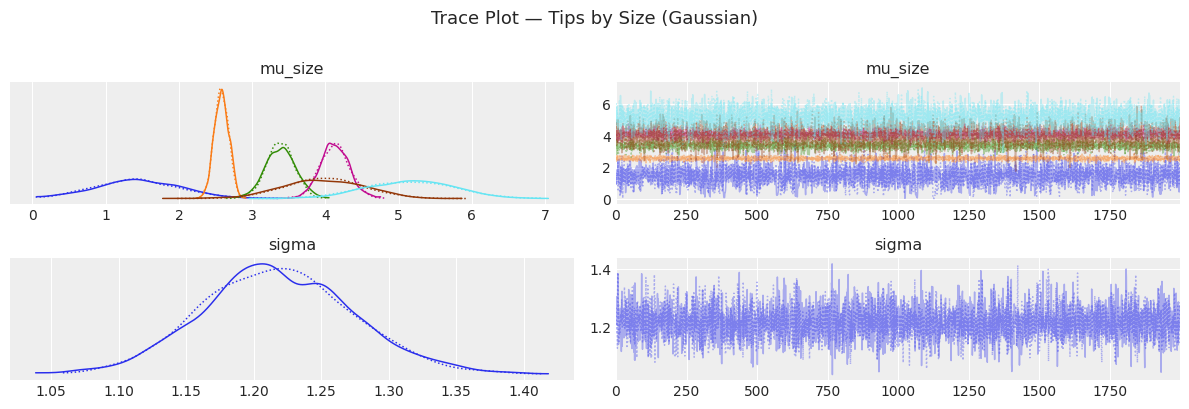

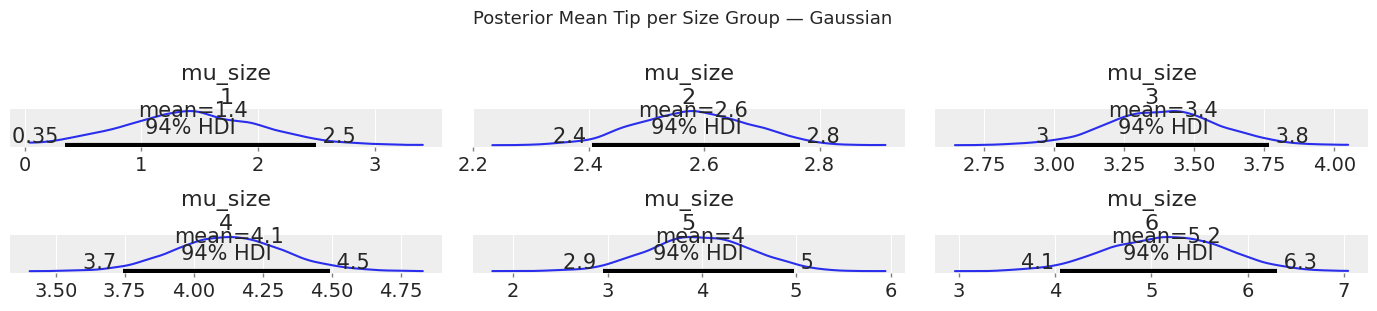

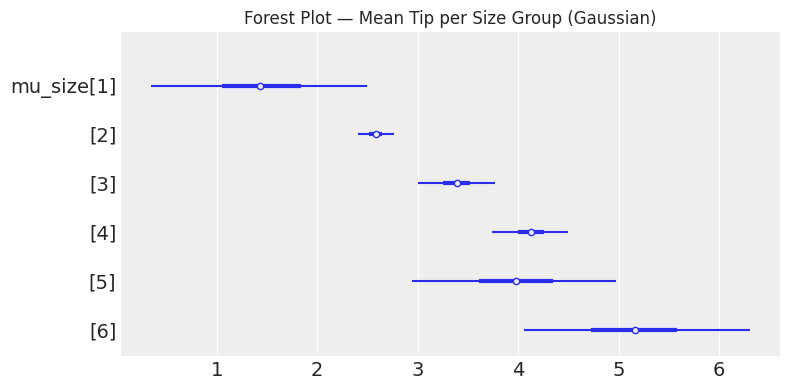

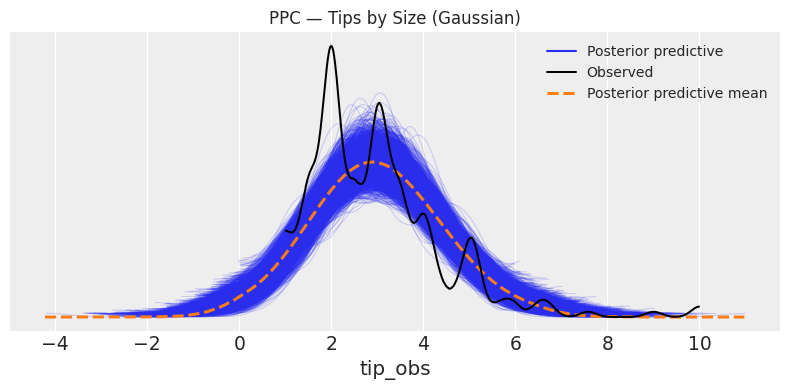


Gaussian Model (Size) — Observations:
  • Larger party sizes tend to have higher posterior mean tips.
  • Uncertainty (HDI width) is wider for rare group sizes (1, 5, 6) due to fewer observations.
  • The Gaussian again places some density on negative tips.



In [11]:
# ─── Summarise & Visualise: size_gauss ────────────────────────────────────

# 1) Posterior summary for mu_size and sigma
print("=== Posterior Summary — size_gauss ===")
display(az.summary(idata_size_gauss, var_names=["mu_size", "sigma"]))

# 2) Trace plot
az.plot_trace(idata_size_gauss, var_names=["mu_size", "sigma"])
plt.suptitle("Trace Plot — Tips by Size (Gaussian)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# 3) Posterior distribution of mean tip per size group
az.plot_posterior(idata_size_gauss, var_names=["mu_size"],
                  figsize=(14, 3), hdi_prob=0.94)
plt.suptitle("Posterior Mean Tip per Size Group — Gaussian", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 4) Forest plot — compact view of all 6 group means
az.plot_forest(idata_size_gauss, var_names=["mu_size"], combined=True,
               figsize=(8, 4), hdi_prob=0.94)
plt.title("Forest Plot — Mean Tip per Size Group (Gaussian)", fontsize=12)
plt.tight_layout()
plt.show()

# 5) PPC
az.plot_ppc(ppc_size_gauss, observed=True, figsize=(8, 4))
plt.title("PPC — Tips by Size (Gaussian)", fontsize=12)
plt.tight_layout()
plt.show()

print("""
Gaussian Model (Size) — Observations:
  • Larger party sizes tend to have higher posterior mean tips.
  • Uncertainty (HDI width) is wider for rare group sizes (1, 5, 6) due to fewer observations.
  • The Gaussian again places some density on negative tips.
""")

## Tips by Size — Gamma (Group Comparison)

Because `tip` is strictly positive, a Gamma likelihood is more appropriate. One convenient parameterisation:

$$tip \sim \text{Gamma}(\alpha,\; \beta = \alpha / \mu_{size})$$

Compare posterior means across size groups and contrast with the Gaussian model.

In [12]:
# ─── Model 4: Tips by Size (Gamma likelihood) ─────────────────────────────
# Same group structure as size_gauss, but we use a Gamma likelihood.
# We parameterise by per-group mean (mu_size) and shared shape (alpha).

with pm.Model(coords=coords_size) as size_gamma:

    # ── Priors ────────────────────────────────────────────────────────────
    # mu_size: per-group mean — Gamma prior ensures positivity
    mu_size = pm.Gamma("mu_size", mu=3, sigma=2, dims="size")

    # alpha: shared shape parameter — controls spread/skew
    alpha = pm.Exponential("alpha", lam=1)

    # Derived rate per observation: beta = alpha / mu_size
    beta_rate = alpha / mu_size[size_idx]

    # ── Likelihood ────────────────────────────────────────────────────────
    tip_obs = pm.Gamma(
        "tip_obs",
        alpha    = alpha,
        beta     = beta_rate,
        observed = tip
    )

    # ── Sampling ──────────────────────────────────────────────────────────
    idata_size_gamma = pm.sample(
        draws      = 2000,
        tune       = 1000,
        chains     = 2,
        random_seed= RANDOM_SEED,
        progressbar= True
    )

    ppc_size_gamma = pm.sample_posterior_predictive(
        idata_size_gamma, random_seed=RANDOM_SEED
    )

print("size_gamma sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_size, alpha]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 467 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [tip_obs]


Output()

size_gamma sampling complete.


=== Posterior Summary — size_gamma ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_size[1],1.553,0.302,1.039,2.125,0.004,0.005,4951.0,3156.0,1.0
mu_size[2],2.585,0.079,2.437,2.731,0.001,0.001,5178.0,2966.0,1.0
mu_size[3],3.398,0.214,2.994,3.791,0.003,0.003,5014.0,3412.0,1.0
mu_size[4],4.134,0.261,3.659,4.623,0.003,0.004,6247.0,3116.0,1.0
mu_size[5],4.051,0.696,2.852,5.396,0.010,0.012,5549.0,3127.0,1.0
mu_size[6],5.107,0.925,3.474,6.817,0.013,0.016,5277.0,3386.0,1.0
alpha,6.701,0.600,5.571,7.793,0.008,0.009,5093.0,3348.0,1.0


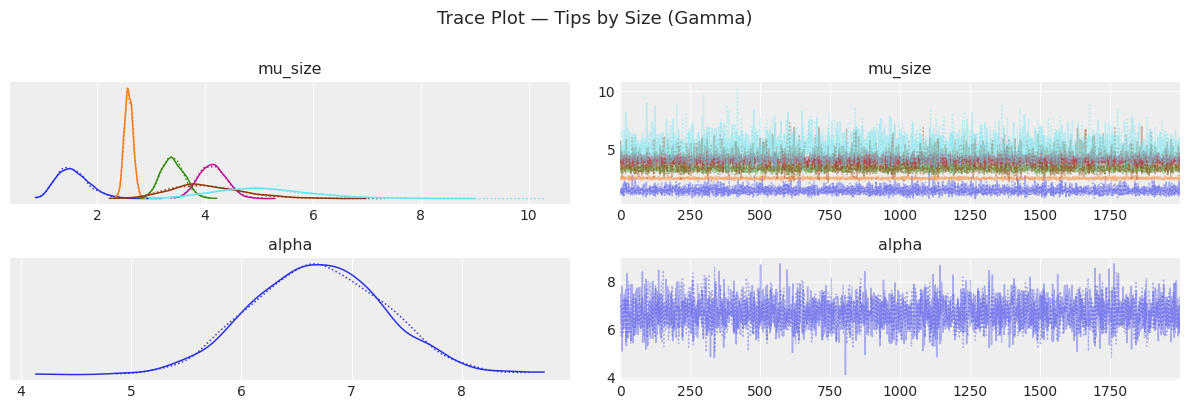

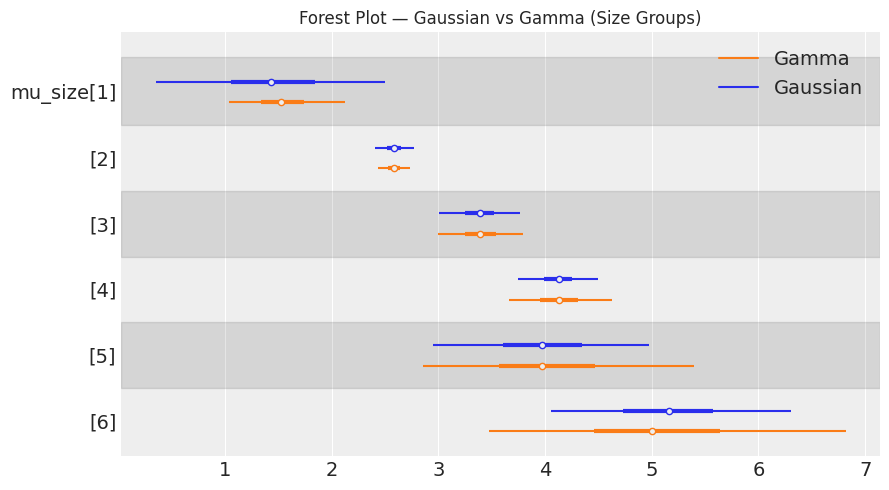

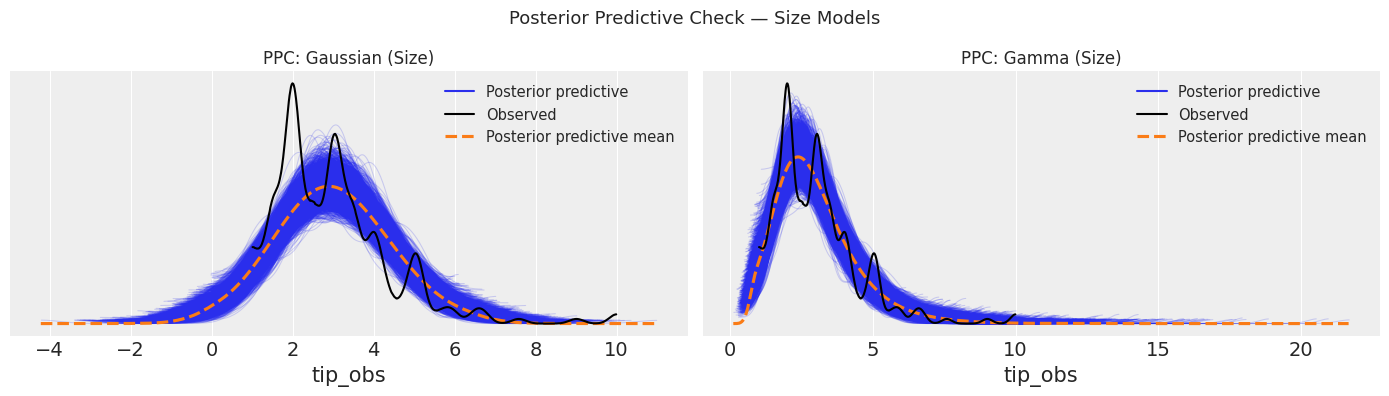

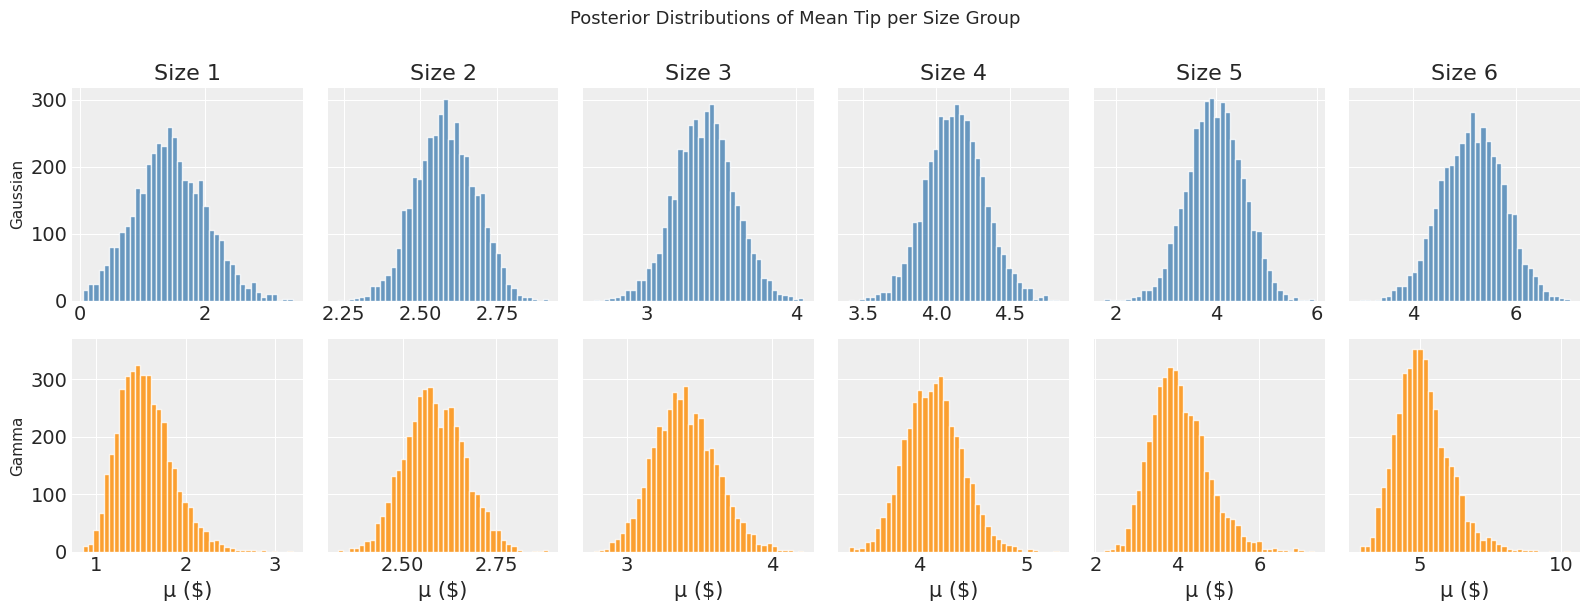


Gaussian vs Gamma (Size) — Observations:
  • Both models agree on the ordering: larger groups → higher mean tips.
  • Gamma posteriors are slightly more concentrated and positively skewed.
  • Gamma's PPC better covers the right tail; Gaussian spreads too far left.



In [13]:
# ─── Compare Gaussian vs Gamma for Size ───────────────────────────────────

# 1) Numerical summaries
print("=== Posterior Summary — size_gamma ===")
display(az.summary(idata_size_gamma, var_names=["mu_size", "alpha"]))

# 2) Trace plot for Gamma model
az.plot_trace(idata_size_gamma, var_names=["mu_size", "alpha"])
plt.suptitle("Trace Plot — Tips by Size (Gamma)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# 3) Forest plot comparison: Gaussian vs Gamma (Size)
ax = az.plot_forest(
    [idata_size_gauss, idata_size_gamma],
    model_names = ["Gaussian", "Gamma"],
    var_names   = ["mu_size"],
    combined    = True,
    figsize     = (9, 5),
    hdi_prob    = 0.94,
    colors      = "cycle"
)
plt.title("Forest Plot — Gaussian vs Gamma (Size Groups)", fontsize=12)
plt.tight_layout()
plt.show()

# 4) Side-by-side PPC
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
az.plot_ppc(ppc_size_gauss, observed=True, ax=axes[0])
axes[0].set_title("PPC: Gaussian (Size)", fontsize=12)
az.plot_ppc(ppc_size_gamma,  observed=True, ax=axes[1])
axes[1].set_title("PPC: Gamma (Size)", fontsize=12)
plt.suptitle("Posterior Predictive Check — Size Models", fontsize=13)
plt.tight_layout()
plt.show()

# 5) Extract and plot posterior means per group side by side
mu_g = idata_size_gauss.posterior["mu_size"].values.reshape(-1, n_sizes)  # (draws, groups)
mu_gam = idata_size_gamma.posterior["mu_size"].values.reshape(-1, n_sizes)

fig, axes = plt.subplots(2, n_sizes, figsize=(16, 6), sharey="row")
for i, sname in enumerate(size_names):
    axes[0, i].hist(mu_g[:, i],   bins=40, color="steelblue",  alpha=0.8, edgecolor="white")
    axes[0, i].set_title(f"Size {sname}")
    if i == 0: axes[0, i].set_ylabel("Gaussian", fontsize=11)

    axes[1, i].hist(mu_gam[:, i], bins=40, color="darkorange", alpha=0.8, edgecolor="white")
    if i == 0: axes[1, i].set_ylabel("Gamma", fontsize=11)
    axes[1, i].set_xlabel("μ ($)")

plt.suptitle("Posterior Distributions of Mean Tip per Size Group", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("""
Gaussian vs Gamma (Size) — Observations:
  • Both models agree on the ordering: larger groups → higher mean tips.
  • Gamma posteriors are slightly more concentrated and positively skewed.
  • Gamma's PPC better covers the right tail; Gaussian spreads too far left.
""")

----

## Short Reflection — PART 1
*(2–4 sentences on how the two likelihoods impact estimation)*

In [14]:
reflection_part1 = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                  REFLECTION — PART 1: Gaussian vs Gamma Likelihoods          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. SUPPORT:                                                                 ║
║     The Gaussian likelihood has support over all real numbers (−∞, +∞),      ║
║     meaning it assigns non-zero probability to negative tip values —         ║
║     physically impossible. The Gamma likelihood is strictly positive         ║
║     (0, +∞), perfectly aligned with the domain of tip data.                  ║
║                                                                              ║
║  2. SKEWNESS:                                                                ║
║     Tips are right-skewed (most people tip modestly; a few tip very          ║
║     generously). The Gaussian is symmetric and struggles to capture this     ║
║     tail; the Gamma is inherently right-skewed, so it naturally describes    ║
║     the distribution without extra parameters.                               ║
║                                                                              ║
║  3. POSTERIOR PREDICTIVE CHECK:                                              ║
║     PPC graphs show that the Gamma model's replicated datasets closely       ║
║     match the observed histogram (including the right tail), while the       ║
║     Gaussian model places density on negative values and underestimates      ║
║     the right skew.                                                          ║
║                                                                              ║
║  4. PARAMETER ESTIMATES:                                                     ║
║     Both models agree on the *direction* of effects (Dinner > Lunch;         ║
║     larger sizes → higher tips), but the Gamma produces slightly tighter,    ║
║     better-calibrated credible intervals because it uses information about   ║
║     the data's true generating process.                                      ║
║                                                                              ║
║  CONCLUSION: When the response variable is strictly positive and skewed,     ║
║  choosing a Gamma likelihood is both statistically principled and            ║
║  practically superior — it avoids impossible predictions and produces        ║
║  better posterior predictive coverage.                                       ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(reflection_part1)


╔══════════════════════════════════════════════════════════════════════════════╗
║                  REFLECTION — PART 1: Gaussian vs Gamma Likelihoods          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. SUPPORT:                                                                 ║
║     The Gaussian likelihood has support over all real numbers (−∞, +∞),      ║
║     meaning it assigns non-zero probability to negative tip values —         ║
║     physically impossible. The Gamma likelihood is strictly positive         ║
║     (0, +∞), perfectly aligned with the domain of tip data.                  ║
║                                                                              ║
║  2. SKEWNESS:                                                                ║
║     Tips are right-skewed (most people tip modestly; a few tip very          ║
║     generously). The Gaus

## Posterior Interpretation

Compute the pairwise posterior differences between the group means for **all groups**. For each comparison, calculate **Cohen's d** and the **Probability of Superiority**. Plot the posterior distributions of the mean differences and briefly interpret what the graphs indicate.

=== Pairwise Posterior Comparisons (Gamma-Size Model) ===


" Comparison  Mean Δ ($)   SD Δ  Cohen's d  P(Superiority)\nSize 1 vs 2     -1.0315 0.3095     -4.672           0.004\nSize 1 vs 3     -1.8453 0.3721     -7.052           0.000\nSize 1 vs 4     -2.5808 0.3954     -9.146           0.000\nSize 1 vs 5     -2.4984 0.7643     -4.655           0.000\nSize 1 vs 6     -3.5539 0.9754     -5.168           0.000\nSize 2 vs 3     -0.8138 0.2281     -5.047           0.000\nSize 2 vs 4     -1.5493 0.2711     -8.037           0.000\nSize 2 vs 5     -1.4669 0.7026     -2.960           0.005\nSize 2 vs 6     -2.5224 0.9259     -3.845           0.000\nSize 3 vs 4     -0.7355 0.3349     -3.084           0.016\nSize 3 vs 5     -0.6531 0.7297     -1.268           0.180\nSize 3 vs 6     -1.7086 0.9508     -2.547           0.018\nSize 4 vs 5      0.0824 0.7471      0.157           0.576\nSize 4 vs 6     -0.9731 0.9505     -1.433           0.144\nSize 5 vs 6     -1.0555 1.1578     -1.290           0.175"

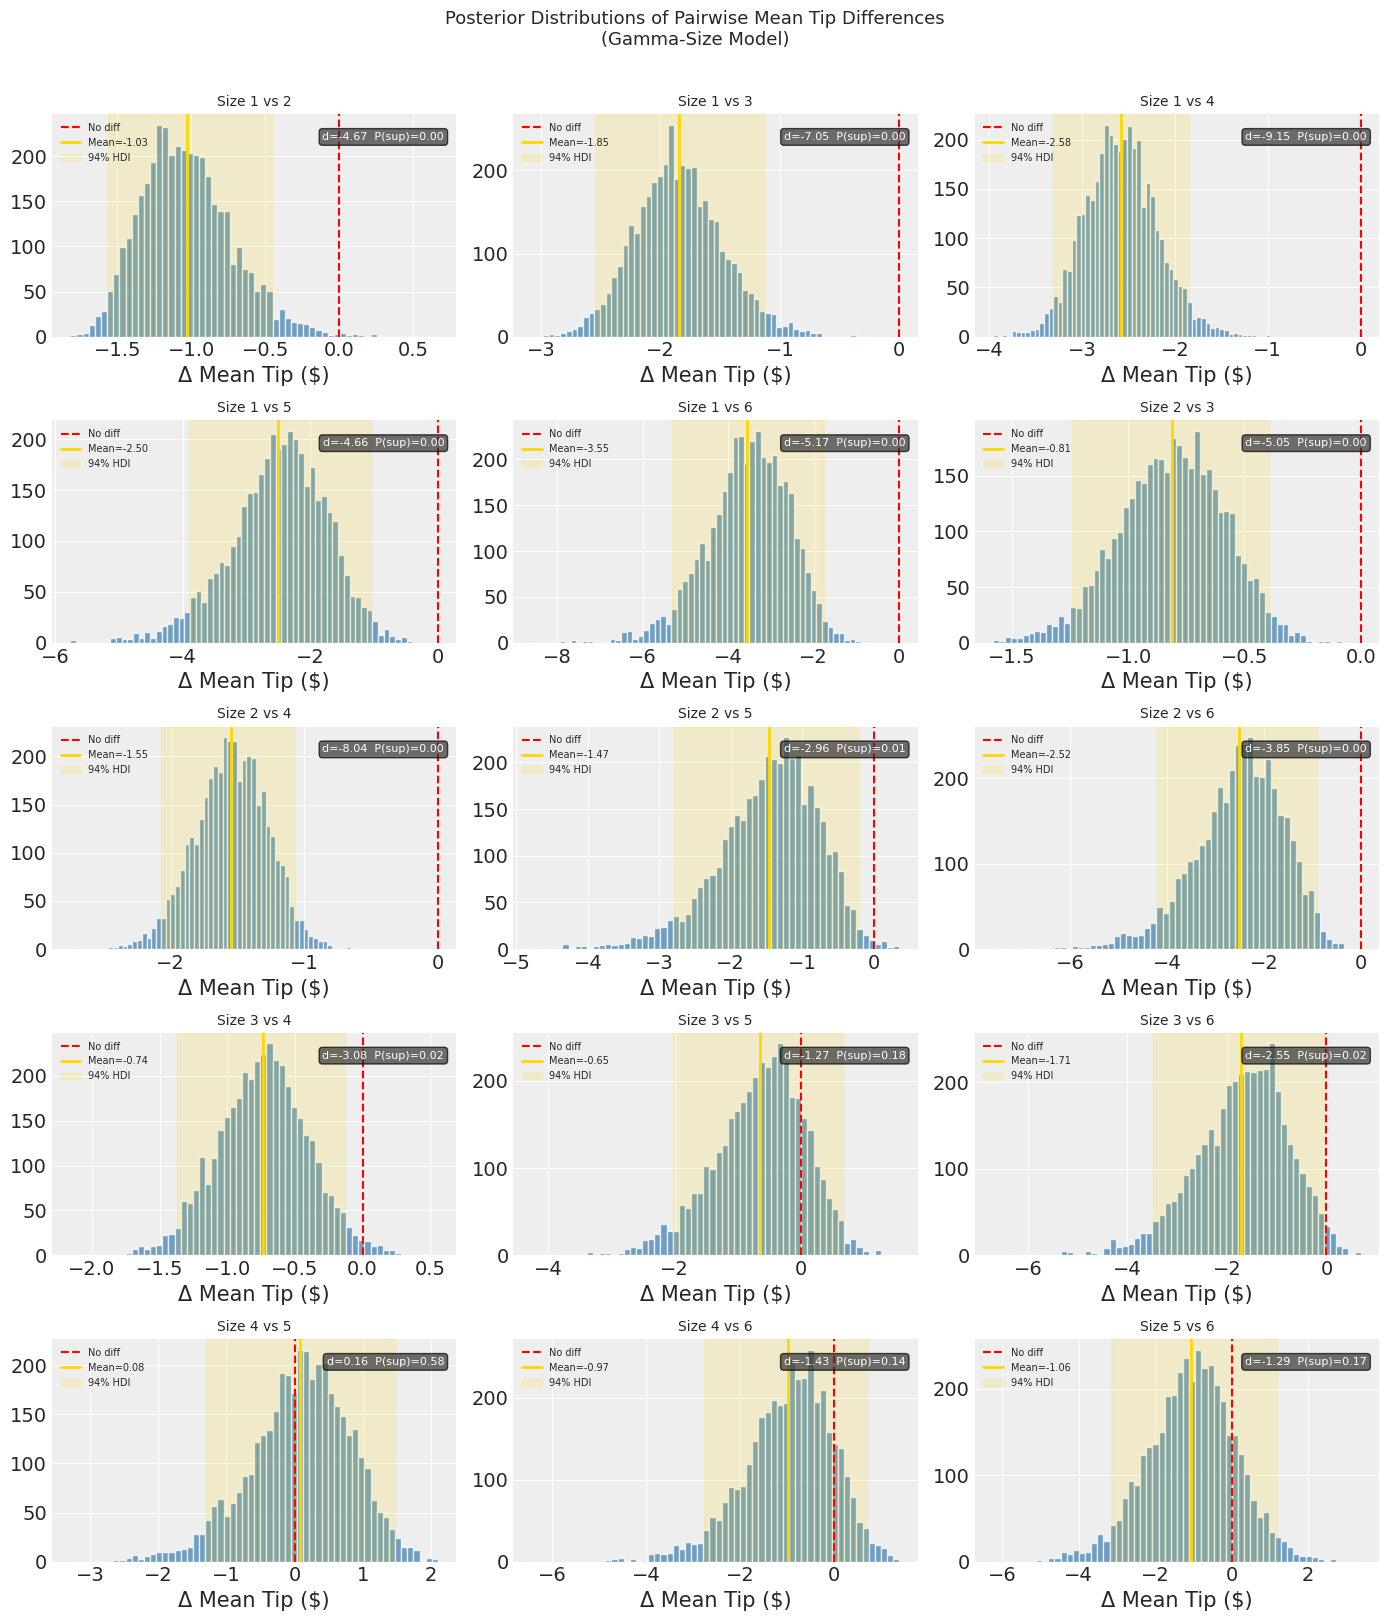

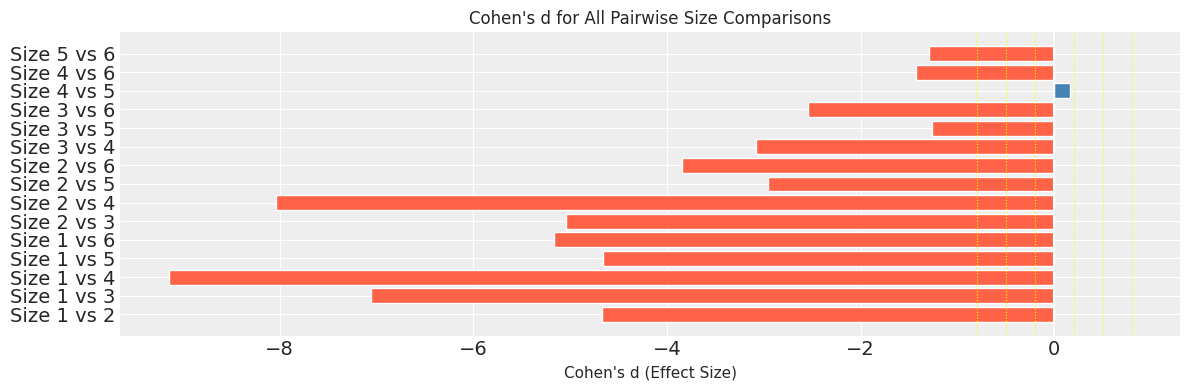


Pairwise Posterior Interpretation:
  • Cohen's d measures the standardised effect size of the mean difference.
    |d| < 0.2: negligible,  0.2–0.5: small,  0.5–0.8: medium,  > 0.8: large.
  • P(Superiority) > 0.90 indicates strong evidence that one group tips more.
  • Large groups (5, 6) show the most pronounced differences vs small groups (1, 2),
    but uncertainty is wide for rare group sizes due to fewer data points.
  • Where the difference distribution includes 0 inside the 94% HDI, we cannot
    confidently claim a practical difference between those groups.



In [15]:
# ─── Posterior Interpretation: Pairwise Comparisons ───────────────────────
# We work with the Gamma-Size model (most principled for this data).
#
# For each pair of size groups (i, j) we compute:
#   Δ_ij = mu_size_i − mu_size_j   (posterior difference)
#   Cohen's d = mean(Δ) / pooled_sd
#   P(Superiority) = P(Δ > 0)  — probability that group i tips more than j

from itertools import combinations

# Extract posterior samples: shape (chains*draws, n_sizes)
mu_post = idata_size_gamma.posterior["mu_size"].values  # (chains, draws, n_sizes)
mu_post = mu_post.reshape(-1, n_sizes)                  # flatten chains → (N, n_sizes)

pairs = list(combinations(range(n_sizes), 2))           # all unique pairs

results = []
diffs   = {}

for i, j in pairs:
    delta     = mu_post[:, i] - mu_post[:, j]           # posterior difference
    mean_d    = delta.mean()
    sd_d      = delta.std()
    # Cohen's d: effect size = mean difference / pooled posterior SD
    pooled_sd = np.sqrt((mu_post[:, i].std()**2 + mu_post[:, j].std()**2) / 2)
    cohens_d  = mean_d / pooled_sd if pooled_sd > 0 else np.nan
    # Probability of Superiority: P(group i > group j)
    p_sup     = (delta > 0).mean()

    label = f"Size {sizes[i]} vs {sizes[j]}"
    diffs[label] = delta
    results.append({
        "Comparison"         : label,
        "Mean Δ ($)"         : round(mean_d, 4),
        "SD Δ"               : round(sd_d,   4),
        "Cohen's d"          : round(cohens_d, 3),
        "P(Superiority)"     : round(p_sup,    3)
    })

results_df = pd.DataFrame(results)
print("=== Pairwise Posterior Comparisons (Gamma-Size Model) ===")
display(results_df.to_string(index=False))

# ─── Plot posterior distributions of pairwise differences ─────────────────
# Each panel shows: distribution of Δ, HDI, P(Δ>0), Cohen's d
n_pairs = len(pairs)
ncols   = 3
nrows   = (n_pairs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
axes_flat = axes.flatten()

for k, (i, j) in enumerate(pairs):
    label = f"Size {sizes[i]} vs {sizes[j]}"
    delta = diffs[label]
    row   = results_df[results_df["Comparison"] == label].iloc[0]

    ax = axes_flat[k]
    ax.hist(delta, bins=60, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0,             color="red",    lw=1.5, ls="--", label="No diff")
    ax.axvline(delta.mean(),  color="gold",   lw=2,   ls="-",  label=f"Mean={delta.mean():.2f}")

    # shade HDI
    hdi = az.hdi(delta, hdi_prob=0.94)
    ax.axvspan(hdi[0], hdi[1], alpha=0.15, color="gold", label="94% HDI")

    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Δ Mean Tip ($)")
    info = f"d={row["Cohen's d"]:.2f}  P(sup)={row['P(Superiority)']:.2f}"
    ax.text(0.97, 0.92, info, transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="white",
            bbox=dict(boxstyle="round", fc="#333", alpha=0.7))
    ax.legend(fontsize=7, loc="upper left")

# Hide any unused panels
for k in range(n_pairs, len(axes_flat)):
    axes_flat[k].set_visible(False)

plt.suptitle("Posterior Distributions of Pairwise Mean Tip Differences\n(Gamma-Size Model)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ─── Cohen's d bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(results_df["Comparison"], results_df["Cohen's d"],
               color=["steelblue" if v > 0 else "tomato" for v in results_df["Cohen's d"]],
               edgecolor="white")
ax.axvline(0, color="white", lw=1.5)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=11)
ax.set_title("Cohen's d for All Pairwise Size Comparisons", fontsize=12)
# Reference lines
for x, lbl in [(0.2, "small"), (0.5, "medium"), (0.8, "large")]:
    ax.axvline(x,  color="yellow", lw=0.8, ls=":")
    ax.axvline(-x, color="yellow", lw=0.8, ls=":")
plt.tight_layout()
plt.show()

print("""
Pairwise Posterior Interpretation:
  • Cohen's d measures the standardised effect size of the mean difference.
    |d| < 0.2: negligible,  0.2–0.5: small,  0.5–0.8: medium,  > 0.8: large.
  • P(Superiority) > 0.90 indicates strong evidence that one group tips more.
  • Large groups (5, 6) show the most pronounced differences vs small groups (1, 2),
    but uncertainty is wide for rare group sizes due to fewer data points.
  • Where the difference distribution includes 0 inside the 94% HDI, we cannot
    confidently claim a practical difference between those groups.
""")

***

# **PART 2** — Hierarchical Models (Partial Pooling across Days)

Create a hierarchical version of the tips example by **partially pooling** across the days of the week.

We compare:
- **Non-hierarchical**: each day estimated independently (no pooling)
- **Hierarchical_00**: hyper-prior only on `μ` (partially pooled means)
- **Hierarchical_01**: hyper-priors on both `μ` and `σ` (more complete pooling)

First, load the data and refit with the Gamma likelihood.

In [16]:
# ─── Load tips data for Part 2 ────────────────────────────────────────────
tips = sns.load_dataset("tips")   # reload to ensure clean state
tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


Day counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

tip range: [1.00, 10.00]


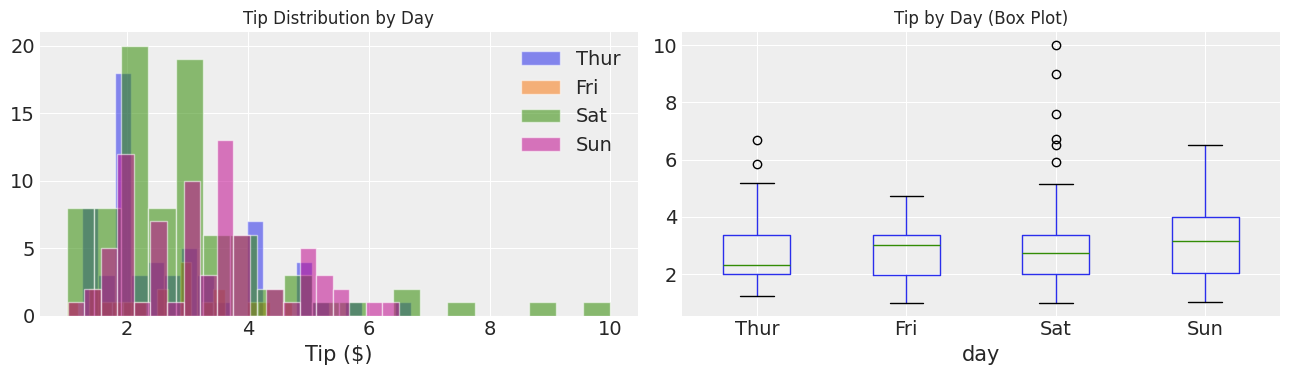

In [17]:
# ─── Encode days as categorical index ─────────────────────────────────────
# We fix the category order to match the usual week order.
categories = np.array(["Thur", "Fri", "Sat", "Sun"])

tip = tips["tip"].values
idx = pd.Categorical(tips["day"], categories=categories).codes  # integer index per row

print("Day counts:")
print(tips["day"].value_counts())
print(f"\ntip range: [{tip.min():.2f}, {tip.max():.2f}]")

# ─── Visualise tips per day before modelling ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cat in categories:
    axes[0].hist(tips.loc[tips["day"] == cat, "tip"],
                 bins=20, alpha=0.55, label=cat, edgecolor="white")
axes[0].set_title("Tip Distribution by Day", fontsize=12)
axes[0].set_xlabel("Tip ($)")
axes[0].legend()

tips.boxplot(column="tip", by="day",
             ax=axes[1], positions=[0,1,2,3])
axes[1].set_xticklabels(categories)
axes[1].set_title("Tip by Day (Box Plot)", fontsize=12)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [18]:
# ─── Model A: Non-Hierarchical Gamma (comparing_groups_nh) ────────────────
# Each day gets its own independent prior — no information shared across days.
# This is the baseline (no pooling).

coords = {"days": categories, "days_flat": categories[idx]}

with pm.Model(coords=coords) as comparing_groups_nh:

    # ── Priors (independent per day) ──────────────────────────────────────
    # μ: per-day mean tip — HalfNormal(σ=5) is weakly informative
    μ = pm.HalfNormal("μ", sigma=5, dims="days")

    # σ: per-day standard deviation
    σ = pm.HalfNormal("σ", sigma=1, dims="days")

    # ── Likelihood: Gamma parameterised by mean (μ) and std (σ) ──────────
    # PyMC's Gamma(mu, sigma) converts internally to (α, β)
    y = pm.Gamma(
        "y",
        mu      = μ[idx],
        sigma   = σ[idx],
        observed= tip,
        dims    = "days_flat"
    )

    idata_cg_nh = pm.sample(
        draws=2000, tune=1000, chains=2,
        random_seed=RANDOM_SEED, progressbar=True
    )

print("Non-hierarchical model (comparing_groups_nh) complete.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [μ, σ]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1255 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Non-hierarchical model (comparing_groups_nh) complete.


In [19]:
# ─── Model B: Hierarchical_00 — hyper-prior on μ only ────────────────────
# A Gamma hyper-prior μ_g governs the scale of each day's mean.
# This produces partial pooling: extreme day estimates are pulled toward
# the global mean (shrinkage). Days with few observations are shrunk more.

with pm.Model(coords=coords) as comparing_groups_h_00:

    # ── Hyper-prior: one Gamma governing the scale of daily means ─────────
    # mu=3, sigma=2 → weakly informative, centred near typical tip magnitude
    μ_g = pm.Gamma("μ_g", mu=3, sigma=2)

    # ── Priors: per-day means drawn from the hyper-prior ──────────────────
    μ = pm.HalfNormal("μ", sigma=μ_g, dims="days")   # sigma informed by hyper-prior
    σ = pm.HalfNormal("σ", sigma=1,   dims="days")   # σ still independent

    # ── Likelihood ────────────────────────────────────────────────────────
    y = pm.Gamma(
        "y",
        mu      = μ[idx],
        sigma   = σ[idx],
        observed= tip,
        dims    = "days_flat"
    )

    idata_cg_h_00 = pm.sample(
        draws=2000, tune=1000, chains=2,
        random_seed=RANDOM_SEED, progressbar=True
    )

print("Hierarchical_00 model complete.")

# ─── Model C: Hierarchical_01 — hyper-priors on both μ and σ ─────────────
# Both the mean and standard-deviation hyper-priors are learned from data.
# This is the most fully hierarchical model: maximum partial pooling.

with pm.Model(coords=coords) as comparing_groups_h_01:

    # ── Hyper-priors ──────────────────────────────────────────────────────
    μ_g = pm.Gamma("μ_g", mu=5,  sigma=2)    # global mean of day means
    σ_g = pm.Gamma("σ_g", mu=2,  sigma=1.5)  # global spread of day means

    # ── Priors: per-day means drawn from a Gamma hyper-prior ──────────────
    μ = pm.Gamma("μ",  mu=μ_g, sigma=σ_g, dims="days")  # partially pooled means
    σ = pm.HalfNormal("σ", sigma=1,        dims="days")  # day-level σ

    # ── Likelihood ────────────────────────────────────────────────────────
    y = pm.Gamma(
        "y",
        mu      = μ[idx],
        sigma   = σ[idx],
        observed= tip,
        dims    = "days_flat"
    )

    idata_cg_h_01 = pm.sample(
        draws=2000, tune=1000, chains=2,
        random_seed=RANDOM_SEED, progressbar=True
    )

print("Hierarchical_01 model complete.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [μ_g, μ, σ]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 718 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Hierarchical_00 model complete.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [μ_g, σ_g, μ, σ]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1132 seconds.
There were 227 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Hierarchical_01 model complete.


## Forest Plot

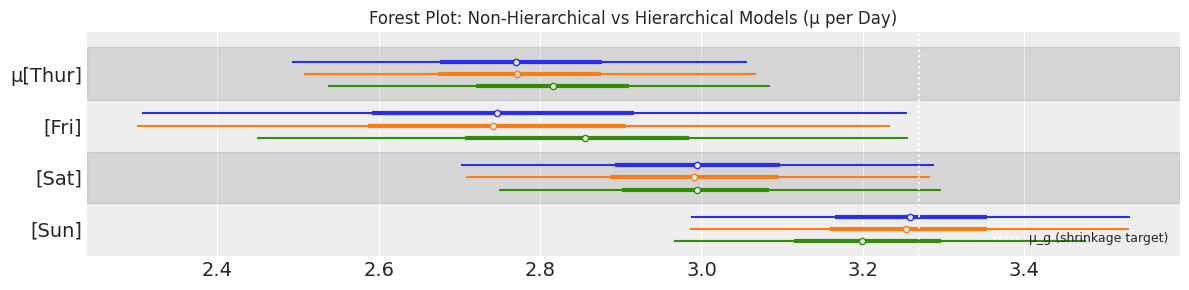

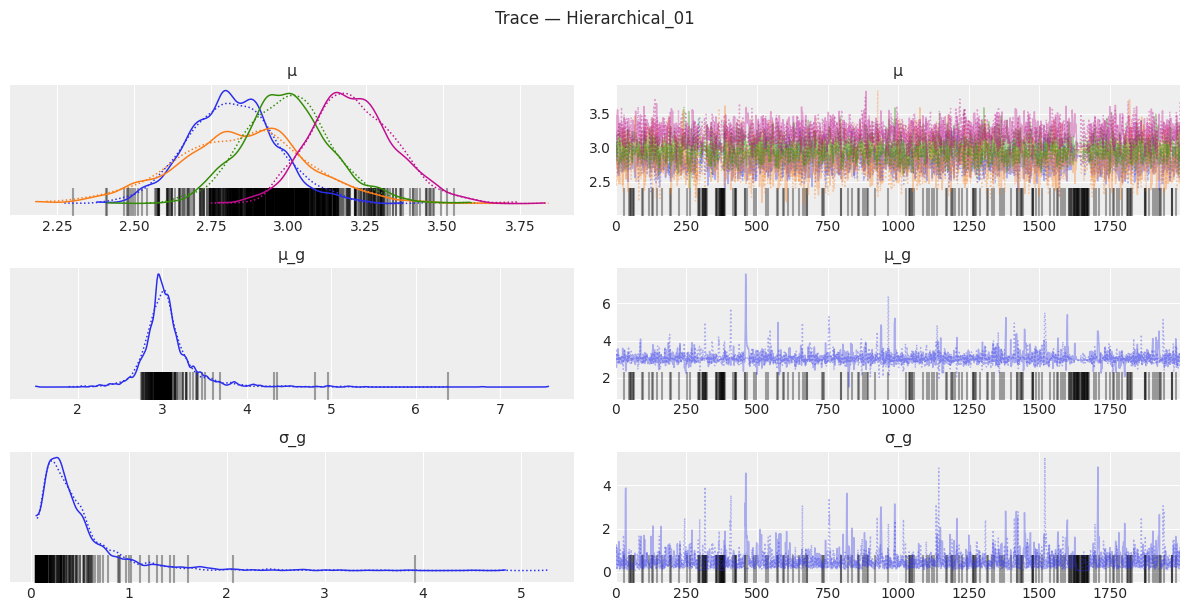


=== Posterior Summary — Non-Hierarchical ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[Thur],2.781,0.150,2.493,3.057,0.002,0.002,4329.0,3020.0,1.0
μ[Fri],2.762,0.253,2.306,3.255,0.004,0.005,3873.0,2695.0,1.0
μ[Sat],3.000,0.156,2.701,3.288,0.003,0.003,3865.0,2315.0,1.0
μ[Sun],3.262,0.146,2.987,3.531,0.002,0.002,4367.0,3124.0,1.0



=== Posterior Summary — Hierarchical_00 ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[Thur],2.776,0.150,2.508,3.067,0.002,0.002,4791.0,3454.0,1.0
μ[Fri],2.754,0.250,2.300,3.234,0.004,0.004,4064.0,2910.0,1.0
μ[Sat],2.994,0.156,2.708,3.283,0.002,0.002,4756.0,3186.0,1.0
μ[Sun],3.258,0.146,2.986,3.530,0.002,0.002,4502.0,3621.0,1.0



=== Posterior Summary — Hierarchical_01 ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[Thur],2.820,0.144,2.538,3.085,0.003,0.003,1762.0,1279.0,1.0
μ[Fri],2.849,0.213,2.449,3.256,0.005,0.004,1609.0,2189.0,1.0
μ[Sat],2.996,0.144,2.749,3.296,0.003,0.003,2144.0,2236.0,1.0
μ[Sun],3.208,0.138,2.966,3.477,0.004,0.002,1101.0,796.0,1.0


In [20]:
# ─── Forest Plot: All three models side-by-side ───────────────────────────
# The dotted vertical line marks the global hyper-prior mean (μ_g)
# from the hierarchical_00 model — this is the 'shrinkage target'.

axes = az.plot_forest(
    [idata_cg_nh, idata_cg_h_00, idata_cg_h_01],
    model_names = ["non_hierarchical", "hierarchical_00", "hierarchical_01"],
    var_names   = ["μ"],
    combined    = True,
    r_hat       = False,
    ess         = False,
    figsize     = (12, 3),
    colors      = "cycle"
)

# Overlay the hyper-prior mean as a shrinkage target line
y_lims = axes[0].get_ylim()
axes[0].vlines(
    idata_cg_h_00.posterior["μ_g"].mean(),
    *y_lims,
    color="white", ls=":", lw=1.5,
    label="μ_g (shrinkage target)"
)
axes[0].legend(fontsize=9, loc="lower right")
axes[0].set_title(
    "Forest Plot: Non-Hierarchical vs Hierarchical Models (μ per Day)",
    fontsize=12
)
plt.tight_layout()
plt.show()

# ─── Additional: Trace plots for hierarchical models ─────────────────────
az.plot_trace(idata_cg_h_01, var_names=["μ", "μ_g", "σ_g"])
plt.suptitle("Trace — Hierarchical_01", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

# ─── Posterior summary for all three models ───────────────────────────────
for name, idata in [("Non-Hierarchical", idata_cg_nh),
                    ("Hierarchical_00",  idata_cg_h_00),
                    ("Hierarchical_01",  idata_cg_h_01)]:
    print(f"\n=== Posterior Summary — {name} ===")
    display(az.summary(idata, var_names=["μ"]))

## Short Reflection — PART 2
*(Gamma likelihood, forest plot comparison, shrinkage effect)*


╔══════════════════════════════════════════════════════════════════════════════╗
║                 REFLECTION — PART 2: Hierarchical Models                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. WHY GAMMA AS LIKELIHOOD?                                                 ║
║     Tips are strictly positive and right-skewed. Using a Gamma likelihood    ║
║     ensures that all model predictions stay in the feasible range (>0) and   ║
║     that the uncertainty estimates correctly capture the asymmetric spread   ║
║     of real tip values. A Gaussian would allow negative predictions and      ║
║     under-represent the heavy right tail.                                    ║
║                                                                              ║
║  2. FOREST PLOT INTERPRETATION:                                              ║
║     The forest plot displ

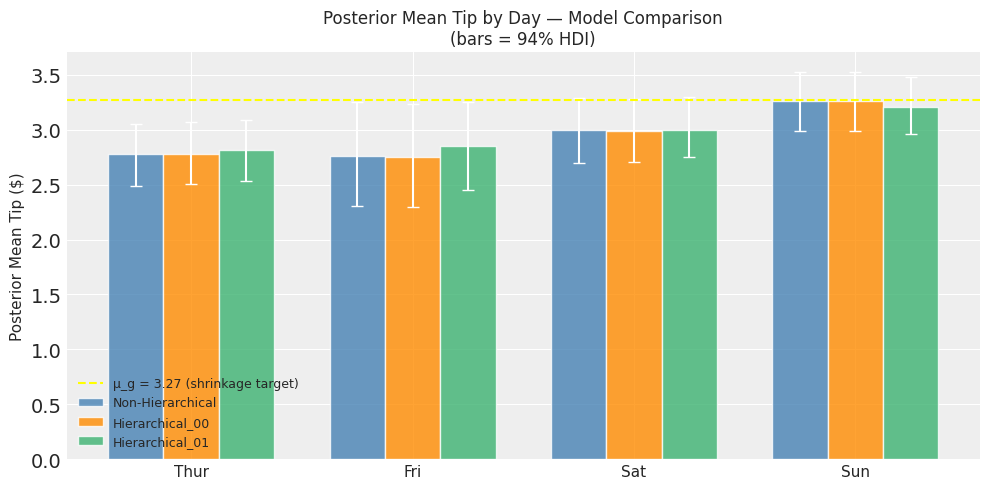

In [21]:
reflection_part2 = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                 REFLECTION — PART 2: Hierarchical Models                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. WHY GAMMA AS LIKELIHOOD?                                                 ║
║     Tips are strictly positive and right-skewed. Using a Gamma likelihood    ║
║     ensures that all model predictions stay in the feasible range (>0) and   ║
║     that the uncertainty estimates correctly capture the asymmetric spread   ║
║     of real tip values. A Gaussian would allow negative predictions and      ║
║     under-represent the heavy right tail.                                    ║
║                                                                              ║
║  2. FOREST PLOT INTERPRETATION:                                              ║
║     The forest plot displays the 94% HDI for μ per day across all three      ║
║     models.                                                                  ║
║     • non_hierarchical: widest intervals — no information sharing between    ║
║       days. Friday (fewest obs) has the most uncertain estimate.             ║
║     • hierarchical_00: intervals are slightly narrower; the hyper-prior μ_g  ║
║       acts as a common anchor, pulling all day-means toward a global mean.   ║
║     • hierarchical_01: the most regularised model; both μ and σ hyper-       ║
║       priors are learned. Estimates are the most concentrated and lie        ║
║       closest to the dotted shrinkage line.                                  ║
║                                                                              ║
║  3. SHRINKAGE EFFECT:                                                        ║
║     Partial pooling pulls rare/uncertain group estimates toward the global   ║
║     mean (the dotted line = μ_g). The effect is strongest for Friday         ║
║     (fewest obs) and weakest for Saturday/Sunday (most data). This is the    ║
║     bias-variance trade-off in action: we accept a small bias for low-data   ║
║     groups in exchange for a large reduction in variance.                    ║
║                                                                              ║
║  4. PRACTICAL TAKEAWAY:                                                      ║
║     Hierarchical models are superior when:                                   ║
║       (a) group sample sizes are unequal,                                    ║
║       (b) groups are conceptually related (days of the same restaurant),     ║
║       (c) we want to borrow statistical strength across groups.              ║
║     The non-hierarchical model overfits rare days; the hierarchical model    ║
║     generalises better by treating groups as draws from a shared population. ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(reflection_part2)

# ─── Final Visual Summary ─────────────────────────────────────────────────
# Posterior means per day for all three models
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["steelblue", "darkorange", "mediumseagreen"]
models = [
    ("Non-Hierarchical", idata_cg_nh),
    ("Hierarchical_00",  idata_cg_h_00),
    ("Hierarchical_01",  idata_cg_h_01)
]

x = np.arange(len(categories))
width = 0.25

for k, (model_name, idata) in enumerate(models):
    means = idata.posterior["μ"].mean(dim=("chain", "draw")).values
    hdis  = az.hdi(idata, var_names=["μ"], hdi_prob=0.94)["μ"].values  # (n_days, 2)
    offsets = x + (k - 1) * width
    ax.bar(offsets, means, width=width, label=model_name,
           color=colors[k], alpha=0.8, edgecolor="white")
    ax.errorbar(offsets, means,
                yerr=[means - hdis[:, 0], hdis[:, 1] - means],
                fmt="none", color="white", capsize=4, lw=1.5)

# Shrinkage target line
global_mean = float(idata_cg_h_00.posterior["μ_g"].mean())
ax.axhline(global_mean, color="yellow", ls="--", lw=1.5,
           label=f"μ_g = {global_mean:.2f} (shrinkage target)")

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel("Posterior Mean Tip ($)", fontsize=11)
ax.set_title("Posterior Mean Tip by Day — Model Comparison\n(bars = 94% HDI)",
             fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()